In [3]:
#!pip install torch torch-geometric

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [4]:
# Define the edge indices (source, target)
edge_index = torch.tensor([
    [0, 1, 1, 2, 3, 3],
    [1, 0, 2, 1, 2, 0]
], dtype=torch.long)

# Define node features (4 nodes, each with 3 features)
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12]
], dtype=torch.float)

# Create a PyTorch Geometric data object
data = Data(x=x, edge_index=edge_index)

In [5]:
# Define the model

class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(3, 4)  # First layer: 3 input features, 4 output features
        self.conv2 = GCNConv(4, 2)  # Second layer: 4 input features, 2 output features

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

# Instantiate the model
model = GCN()

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

# Example target for demonstration (same shape as output)
target = torch.tensor([
    [0, 1],
    [1, 0],
    [0, 1],
    [1, 0]
], dtype=torch.float)

# Training loop
model.train()

for epoch in range(20):
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out, target)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item()}')

Epoch 1, Loss: 8.39107608795166
Epoch 2, Loss: 6.729580402374268
Epoch 3, Loss: 5.326951026916504
Epoch 4, Loss: 4.161012172698975
Epoch 5, Loss: 3.207643508911133
Epoch 6, Loss: 2.4415862560272217
Epoch 7, Loss: 1.837369441986084
Epoch 8, Loss: 1.3722093105316162
Epoch 9, Loss: 1.0240198373794556
Epoch 10, Loss: 0.7632004618644714
Epoch 11, Loss: 0.5729458332061768
Epoch 12, Loss: 0.4401592016220093
Epoch 13, Loss: 0.35198599100112915
Epoch 14, Loss: 0.2973532974720001
Epoch 15, Loss: 0.2693816125392914
Epoch 16, Loss: 0.2601129412651062
Epoch 17, Loss: 0.2648100256919861
Epoch 18, Loss: 0.2788204550743103
Epoch 19, Loss: 0.2955158054828644
Epoch 20, Loss: 0.31464990973472595


In [16]:
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import train_test_split_edges

In [17]:
# Load the Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')

# Get the data object
data = dataset[0]

# Split the edges for link prediction
data = train_test_split_edges(data)

/tmp/ipykernel_1591/194395581.py:8: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data = train_test_split_edges(data)


In [20]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, out_channels)
        self.lin = Linear(out_channels, 1)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        z = z[edge_label_index[0]] * z[edge_label_index[1]]
        return torch.sigmoid(self.lin(z).squeeze())
    
    def forward(self, data):
        z = self.encode(data.x, data.train_pos_edge_index)
        return z
    
    def predict(self, data):
        z = self.forward(data)
        return self.decode(z, data.test_pos_edge_index.t()), self.decode(z, data.test_neg_edge_index.t())

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(dataset.num_features, 16).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCELoss()
from torch_geometric.utils import negative_sampling

# ... (Keep your GCN class definition as is, but ensure self.lin = Linear(16, 1))

def train():
    model.train()
    optimizer.zero_grad()
    
    # 1. Encode nodes
    z = model(data)
    
    # 2. Get positive edges
    pos_edge_index = data.train_pos_edge_index # Shape [2, E]
    
    # 3. Generate negative edges on the fly
    neg_edge_index = negative_sampling(
        edge_index=pos_edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )
    
    # 4. Decode (Notice: No .t() here)
    pos_pred = model.decode(z, pos_edge_index)
    neg_pred = model.decode(z, neg_edge_index)
    
    pos_loss = criterion(pos_pred, torch.ones_like(pos_pred))
    neg_loss = criterion(neg_pred, torch.zeros_like(neg_pred))
    
    loss = pos_loss + neg_loss
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    with torch.no_grad():
        z = model(data)
        # For testing, you can use the pre-split test edges
        pos_pred = model.decode(z, data.test_pos_edge_index)
        neg_pred = model.decode(z, data.test_neg_edge_index)
        
        loss = criterion(pos_pred, torch.ones_like(pos_pred)) + \
               criterion(neg_pred, torch.zeros_like(neg_pred))
        return loss.item()
        
for epoch in range(1, 201):
    loss = train()
    if epoch % 10 == 0:
        test_loss = test()
        print(f'Epoch: {epoch}, Loss: {loss:.4f}, Test Loss: {test_loss:.4f}')



Epoch: 10, Loss: 1.3043, Test Loss: 1.3135
Epoch: 20, Loss: 1.0687, Test Loss: 1.1481
Epoch: 30, Loss: 0.8271, Test Loss: 0.9699
Epoch: 40, Loss: 0.5858, Test Loss: 0.9756
Epoch: 50, Loss: 0.4403, Test Loss: 1.1546
Epoch: 60, Loss: 0.3316, Test Loss: 1.3887
Epoch: 70, Loss: 0.2844, Test Loss: 2.0111
Epoch: 80, Loss: 0.3156, Test Loss: 1.7312
Epoch: 90, Loss: 0.2278, Test Loss: 1.9440
Epoch: 100, Loss: 0.2230, Test Loss: 1.9766
Epoch: 110, Loss: 0.2040, Test Loss: 2.3180
Epoch: 120, Loss: 0.1608, Test Loss: 2.5681
Epoch: 130, Loss: 0.1719, Test Loss: 2.8689
Epoch: 140, Loss: 0.1496, Test Loss: 3.1968
Epoch: 150, Loss: 0.1309, Test Loss: 3.4054
Epoch: 160, Loss: 0.1365, Test Loss: 3.7720
Epoch: 170, Loss: 0.1305, Test Loss: 3.3921
Epoch: 180, Loss: 0.1889, Test Loss: 3.8610
Epoch: 190, Loss: 0.1416, Test Loss: 3.6945
Epoch: 200, Loss: 0.1144, Test Loss: 3.8786


In [23]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, data, mode='test'):
    model.eval()
    with torch.no_grad():
        z = model(data)
        
        # Select the correct edges based on mode
        if mode == 'val':
            pos_edge_index = data.val_pos_edge_index
            neg_edge_index = data.val_neg_edge_index
        else:
            pos_edge_index = data.test_pos_edge_index
            neg_edge_index = data.test_neg_edge_index
        
        # Get predictions
        pos_pred = model.decode(z, pos_edge_index)
        neg_pred = model.decode(z, neg_edge_index)
        
        # Combine predictions and create ground truth labels
        preds = torch.cat([pos_pred, neg_pred], dim=0).cpu().numpy()
        labels = torch.cat([torch.ones(pos_pred.size(0)), 
                            torch.zeros(neg_pred.size(0))], dim=0).cpu().numpy()
        
        # Calculate metrics
        auc = roc_auc_score(labels, preds)
        ap = average_precision_score(labels, preds)
        
        return auc, ap

# --- Training Loop with Pretty Printing ---
print(f"{'Epoch':<10} | {'Loss':<10} | {'AUC':<10} | {'AP':<10}")
print("-" * 45)

for epoch in range(1, 101):
    loss = train()
    
    if epoch % 10 == 0:
        auc, ap = evaluate(model, data, mode='test')
        print(f"{epoch:<10} | {loss:<10.4f} | {auc:<10.4f} | {ap:<10.4f}")

# Final Result
final_auc, final_ap = evaluate(model, data, mode='test')
print("-" * 45)
print(f"Final Test Result: AUC: {final_auc:.4f}, AP: {final_ap:.4f}")

Epoch      | Loss       | AUC        | AP        
---------------------------------------------
10         | 0.0975     | 0.8964     | 0.9126    
20         | 0.0957     | 0.8957     | 0.9115    
30         | 0.1142     | 0.8937     | 0.9098    
40         | 0.0945     | 0.8957     | 0.9107    
50         | 0.1095     | 0.8913     | 0.9080    
60         | 0.1357     | 0.8976     | 0.9081    
70         | 0.1236     | 0.8960     | 0.9121    
80         | 0.0963     | 0.8941     | 0.9092    
90         | 0.1045     | 0.8935     | 0.9099    
100        | 0.0757     | 0.8935     | 0.9104    
---------------------------------------------
Final Test Result: AUC: 0.8935, AP: 0.9104


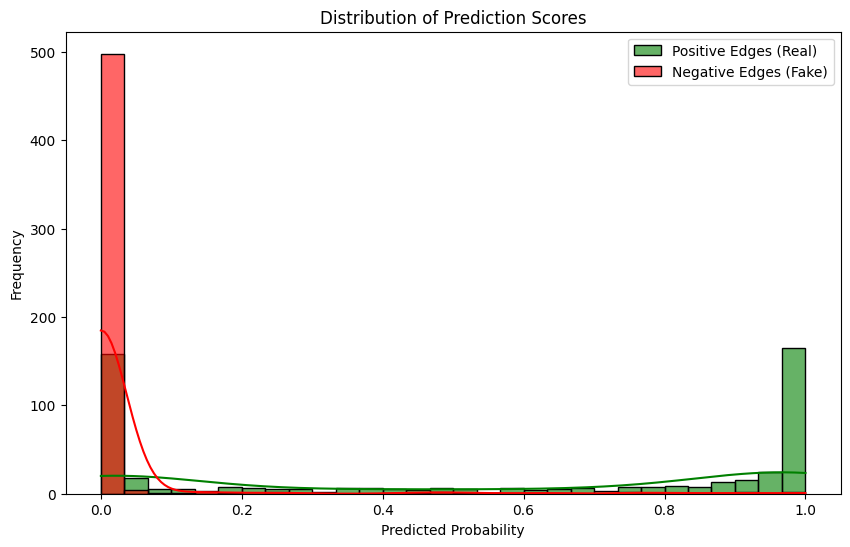

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions(model, data):
    model.eval()
    with torch.no_grad():
        z = model(data)
        pos_pred = model.decode(z, data.test_pos_edge_index).cpu().numpy()
        neg_pred = model.decode(z, data.test_neg_edge_index).cpu().numpy()

    plt.figure(figsize=(10, 6))
    sns.histplot(pos_pred, color="green", label="Positive Edges (Real)", kde=True, bins=30, alpha=0.6)
    sns.histplot(neg_pred, color="red", label="Negative Edges (Fake)", kde=True, bins=30, alpha=0.6)
    plt.title("Distribution of Prediction Scores")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

plot_predictions(model, data)

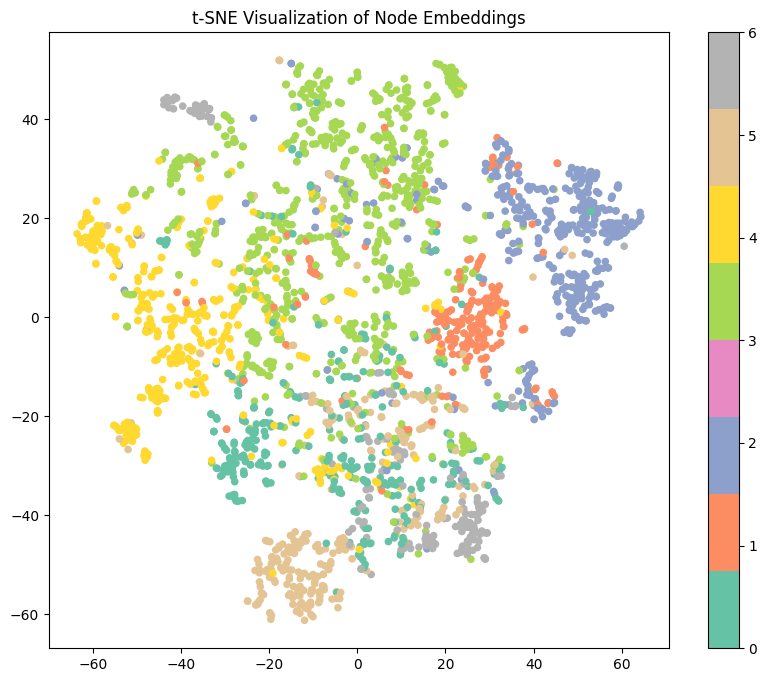

In [25]:
from sklearn.manifold import TSNE

def plot_tsne(model, data):
    model.eval()
    with torch.no_grad():
        z = model(data).cpu().numpy()
        y = data.y.cpu().numpy() # Actual node labels (e.g., "Neural Networks")

    tsne = TSNE(n_components=2, random_state=42)
    z_embedded = tsne.fit_transform(z)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_embedded[:, 0], z_embedded[:, 1], c=y, cmap='Set2', s=20)
    plt.colorbar(scatter)
    plt.title("t-SNE Visualization of Node Embeddings")
    plt.show()

plot_tsne(model, data)

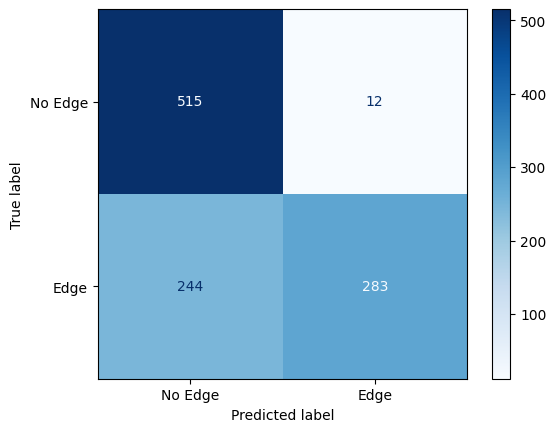

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, data):
    model.eval()
    with torch.no_grad():
        z = model(data)
        pos_pred = model.decode(z, data.test_pos_edge_index)
        neg_pred = model.decode(z, data.test_neg_edge_index)
        
        preds = torch.cat([pos_pred, neg_pred]) > 0.5
        labels = torch.cat([torch.ones(pos_pred.size(0)), torch.zeros(neg_pred.size(0))])
        
    cm = confusion_matrix(labels.cpu(), preds.cpu())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Edge', 'Edge'])
    disp.plot(cmap='Blues')
    plt.show()

plot_confusion_matrix(model, data)

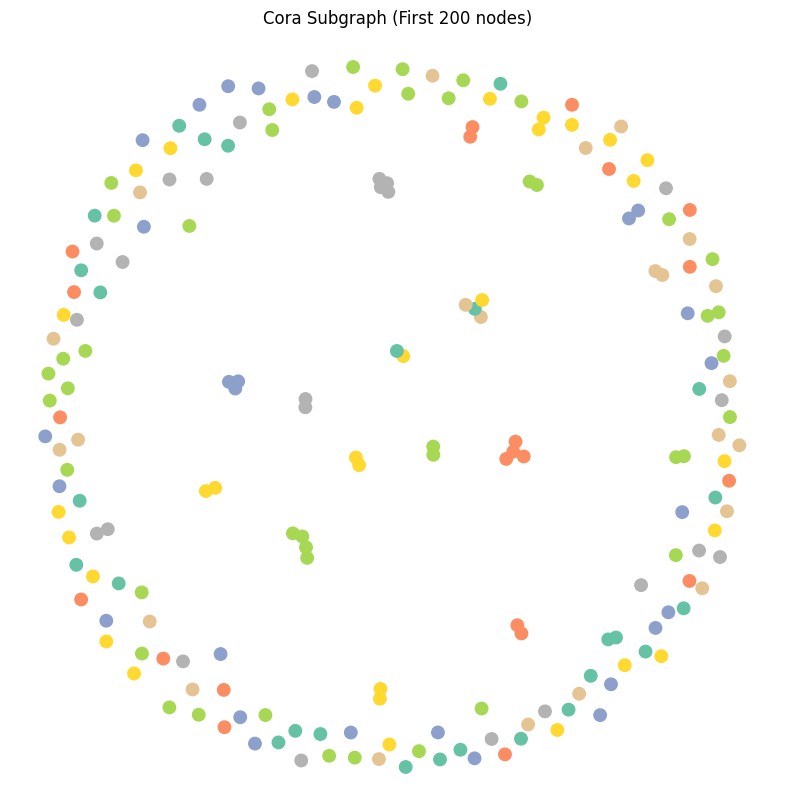

In [33]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_graph(data, num_nodes=200):
    # 1. Temporarily restore edge_index so to_networkx can find it
    # We use the training edges for the visualization
    data.edge_index = data.train_pos_edge_index
    
    # 2. Convert to NetworkX
    G = to_networkx(data, to_undirected=True)
    node_subset = list(range(min(num_nodes, data.num_nodes)))
    subgraph = G.subgraph(node_subset)

    # 3. Get labels for the subset
    labels = data.y[node_subset].cpu().numpy()
    
    # 4. Define layout
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(subgraph, seed=42) 

    # 5. Draw
    nx.draw_networkx_nodes(
        subgraph, pos, 
        node_size=80, 
        node_color=labels, 
        cmap=plt.cm.Set2
    )
    nx.draw_networkx_edges(subgraph, pos, alpha=0.2, edge_color="gray")
    
    plt.title(f"Cora Subgraph (First {num_nodes} nodes)")
    plt.axis('off')
    plt.show()
    
    # 6. Clean up (Optional: remove the temp edge_index if you want)
    del data.edge_index

visualize_graph(data, num_nodes=200)

In [39]:
from pyvis.network import Network
import matplotlib.colors as mcolors

def visualize_interactive(data, num_nodes=150):
    # 1. Fix the AttributeError by temporarily restoring edge_index
    data.edge_index = data.train_pos_edge_index
    
    # 2. Convert to NetworkX
    G = to_networkx(data, to_undirected=True)
    subgraph = G.subgraph(list(range(min(num_nodes, data.num_nodes))))
    
    # 3. Setup Pyvis
    net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')
    
    # 4. Map the Cora classes to actual colors for the interactive nodes
    # This ensures your clusters match the colors in your t-SNE
    cmap = plt.cm.Set2
    for node in subgraph.nodes:
        node_class = int(data.y[node])
        rgba = cmap(node_class / 7) # Cora has 7 classes
        hex_color = mcolors.to_hex(rgba)
        net.add_node(node, label=f"Node {node} (Class {node_class})", color=hex_color)

    # 5. Add edges
    for edge in subgraph.edges:
        net.add_edge(edge[0], edge[1], color='gray')
    
    # 6. Clean up the data object
    del data.edge_index
    
    # 7. Generate the file
    net.show('cora_interactive.html', notebook=False)
    print("Success! Open 'cora_interactive.html' in your browser to explore.")

visualize_interactive(data)

cora_interactive.html
Success! Open 'cora_interactive.html' in your browser to explore.


/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'cora_interactive.html'


In [40]:
from sklearn.metrics import accuracy_score

def print_final_report(model, data):
    model.eval()
    with torch.no_grad():
        z = model(data)
        
        # Calculate final link prediction metrics
        pos_pred = model.decode(z, data.test_pos_edge_index)
        neg_pred = model.decode(z, data.test_neg_edge_index)
        
        # 0.5 is our decision threshold
        acc = accuracy_score(
            torch.cat([torch.ones(pos_pred.size(0)), torch.zeros(neg_pred.size(0))]).cpu(),
            torch.cat([pos_pred, neg_pred]).cpu() > 0.5
        )
        
        print("="*30)
        print("FINAL PROJECT SUMMARY")
        print("="*30)
        print(f"Link Prediction Accuracy: {acc*100:.2f}%")
        print(f"Number of Clusters Found: {len(torch.unique(data.y))}")
        print("Visualizations saved: t-SNE Plot, Interactive Graph")
        print("="*30)

print_final_report(model, data)

FINAL PROJECT SUMMARY
Link Prediction Accuracy: 75.71%
Number of Clusters Found: 7
Visualizations saved: t-SNE Plot, Interactive Graph
